<a href="https://colab.research.google.com/github/yogitapal11jan/UH_Thesis_Checker/blob/main/Excipient%20screening%20Heatmap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

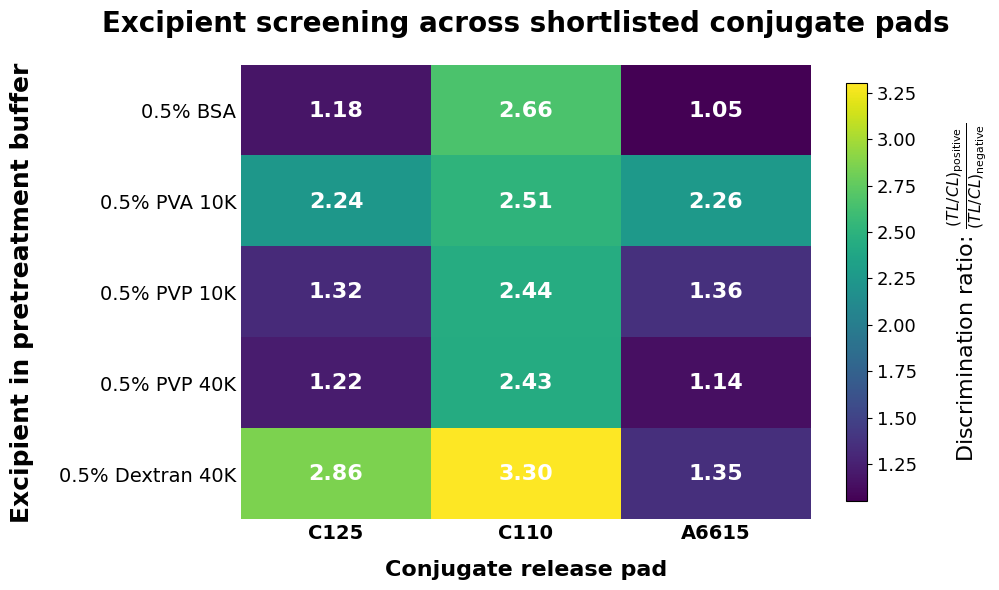

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================================
# HEATMAP: Excipient screening
# =========================================

# Data directly incorporated
heatmap_df = pd.DataFrame(
    {
        "C125": [1.18, 2.24, 1.32, 1.22, 2.86],
        "C110": [2.66, 2.51, 2.44, 2.43, 3.30],
        "A6615": [1.05, 2.26, 1.36, 1.14, 1.35],
    },
    index=[
        "0.5% BSA",
        "0.5% PVA 10K",
        "0.5% PVP 10K",
        "0.5% PVP 40K",
        "0.5% Dextran 40K",
    ],
)

fig, ax = plt.subplots(figsize=(10, 6))

im = ax.imshow(heatmap_df.values, aspect="auto")

ax.set_title(
    "Excipient screening across shortlisted conjugate pads",
    fontsize=20,
    fontweight="bold",
    pad=24
)

ax.set_xlabel(
    "Conjugate release pad",
    fontsize=16,
    fontweight="bold",
    labelpad=12
)

ax.set_ylabel(
    "Excipient in pretreatment buffer",
    fontsize=18,
    fontweight="bold",
    labelpad=18
)

ax.set_xticks(np.arange(len(heatmap_df.columns)))
ax.set_xticklabels(heatmap_df.columns, fontsize=14, fontweight="bold")

ax.set_yticks(np.arange(len(heatmap_df.index)))
ax.set_yticklabels(heatmap_df.index, fontsize=14)

# Values inside cells
vals = heatmap_df.values
for i in range(vals.shape[0]):
    for j in range(vals.shape[1]):
        ax.text(
            j, i, f"{vals[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=16,
            fontweight="bold",
            color="white"
        )

# Remove borders/spines
ax.tick_params(axis="both", which="both", length=0)
for spine in ax.spines.values():
    spine.set_visible(False)

# Colorbar
cbar = fig.colorbar(im, ax=ax, shrink=0.92)
cbar.set_label(
    r"Discrimination ratio: $\frac{(TL/CL)_{\mathrm{positive}}}{(TL/CL)_{\mathrm{negative}}}$",
    fontsize=16,
    labelpad=20
)
cbar.ax.tick_params(labelsize=13)

plt.tight_layout()
plt.show()

# Optional save
# fig.savefig("excipient_screening_heatmap.png", dpi=300, bbox_inches="tight")

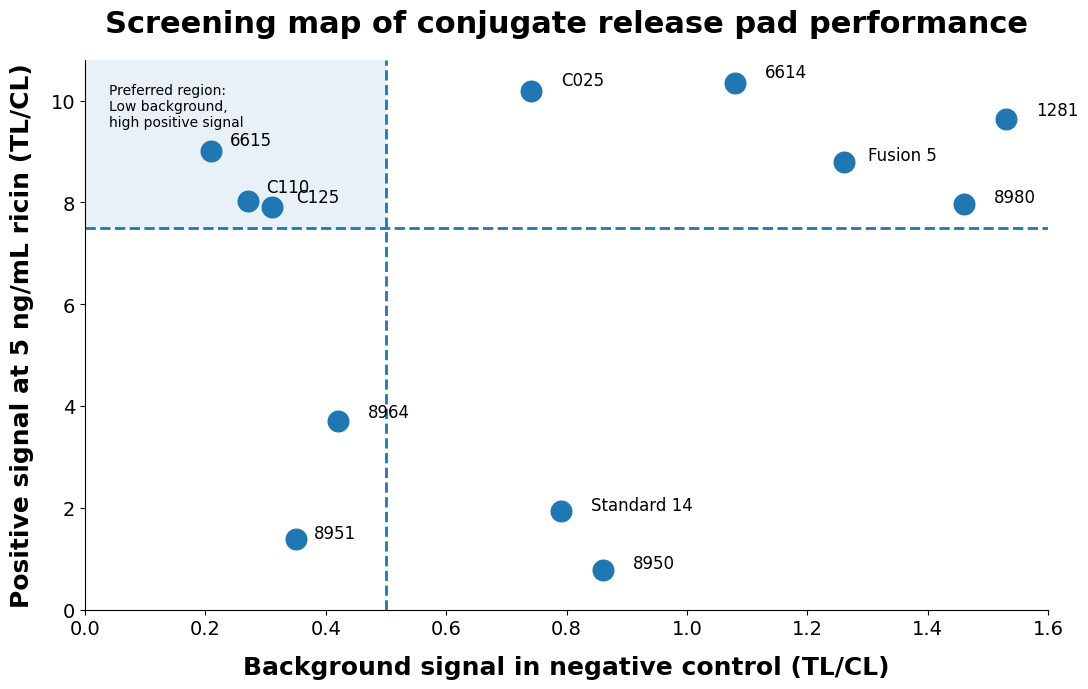

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# =========================================
# 2D SCATTER PLOT: Screening map
# =========================================

# Data directly incorporated
plot_df = pd.DataFrame({
    "Label": [
        "Fusion 5", "6614", "8950", "8951", "8964", "8980",
        "1281", "6615", "C110", "C025", "C125", "Standard 14"
    ],
    "Negative TL/CL": [1.26, 1.08, 0.86, 0.35, 0.42, 1.46, 1.53, 0.21, 0.27, 0.74, 0.31, 0.79],
    "Positive TL/CL": [8.79, 10.35, 0.77, 1.38, 3.70, 7.96, 9.64, 9.00, 8.02, 10.19, 7.91, 1.94],
})

# Plot settings
x_cut = 0.50
y_cut = 7.50
xmax = 1.60
ymax = 10.80

fig, ax = plt.subplots(figsize=(11, 7))

# Shaded preferred region
preferred_region = Rectangle((0, y_cut), x_cut, ymax - y_cut, alpha=0.10)
ax.add_patch(preferred_region)

# Scatter points
ax.scatter(plot_df["Negative TL/CL"], plot_df["Positive TL/CL"], s=220)

# Quadrant guide lines
ax.axvline(x=x_cut, linestyle="--", linewidth=2)
ax.axhline(y=y_cut, linestyle="--", linewidth=2)

# Custom offsets to reduce overlap
offsets = {
    "Fusion 5": (0.04, 0.05),
    "6614": (0.05, 0.12),
    "8950": (0.05, 0.05),
    "8951": (0.03, 0.02),
    "8964": (0.05, 0.08),
    "8980": (0.05, 0.04),
    "1281": (0.05, 0.08),
    "6615": (0.03, 0.12),
    "C110": (0.03, 0.18),
    "C025": (0.05, 0.12),
    "C125": (0.04, 0.10),
    "Standard 14": (0.05, 0.02),
}

# Add labels
for _, row in plot_df.iterrows():
    x = row["Negative TL/CL"]
    y = row["Positive TL/CL"]
    label = row["Label"]
    dx, dy = offsets.get(label, (0.03, 0.08))

    ax.annotate(
        label,
        (x, y),
        xytext=(x + dx, y + dy),
        fontsize=12
    )

# Preferred region text
ax.text(
    0.04, 10.35,
    "Preferred region:\nLow background,\nhigh positive signal",
    fontsize=10,
    va="top",
    ha="left"
)

# Title and labels
ax.set_title(
    "Screening map of conjugate release pad performance",
    fontsize=22,
    fontweight="bold",
    pad=20
)

ax.set_xlabel(
    "Background signal in negative control (TL/CL)",
    fontsize=18,
    fontweight="bold",
    labelpad=12
)

ax.set_ylabel(
    "Positive signal at 5 ng/mL ricin (TL/CL)",
    fontsize=18,
    fontweight="bold",
    labelpad=12
)

ax.set_xlim(0, xmax)
ax.set_ylim(0, ymax)

# Clean look
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="both", labelsize=14)

plt.tight_layout()
plt.show()

# Optional save
# fig.savefig("screening_map_conjugate_pad.png", dpi=300, bbox_inches="tight")

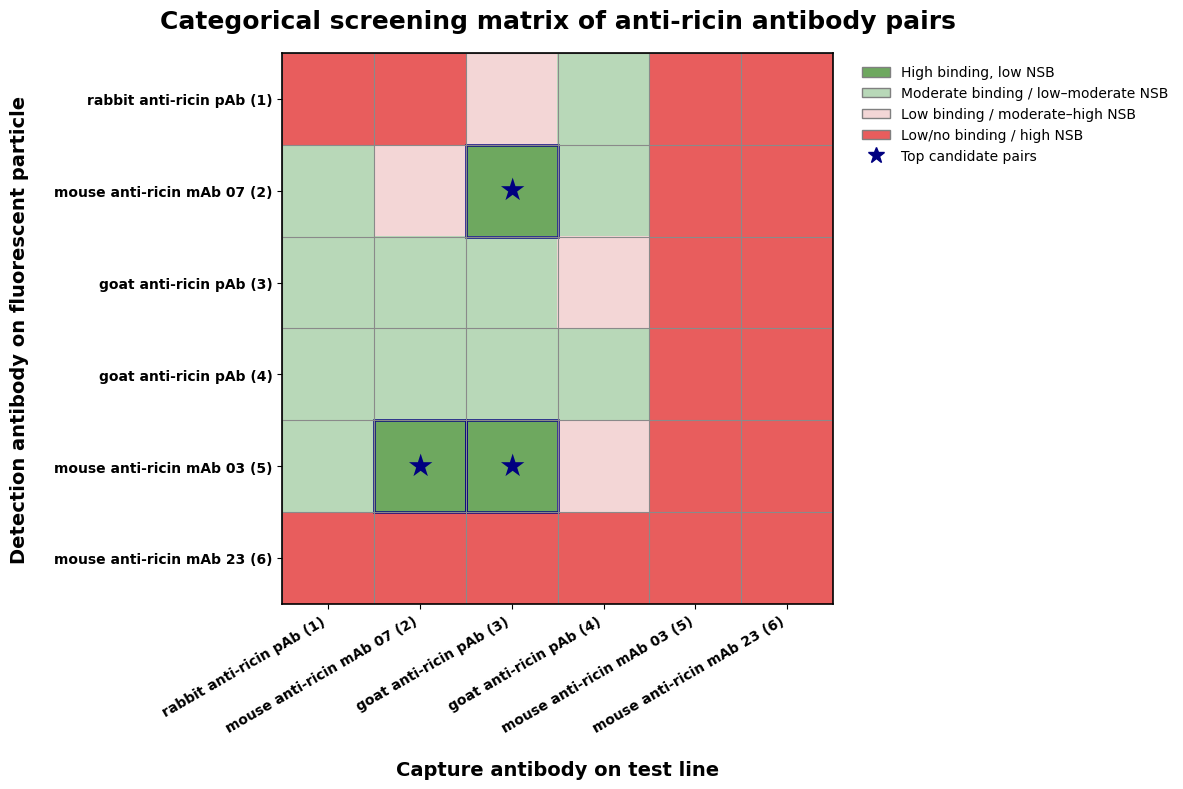

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch, Rectangle
from matplotlib.lines import Line2D

# =========================================================
# 1. Antibody labels
# =========================================================
antibodies = [
    "rabbit anti-ricin pAb (1)",
    "mouse anti-ricin mAb 07 (2)",
    "goat anti-ricin pAb (3)",
    "goat anti-ricin pAb (4)",
    "mouse anti-ricin mAb 03 (5)",
    "mouse anti-ricin mAb 23 (6)"
]

# =========================================================
# 2. Categorical performance matrix
# =========================================================
# 0 = low or no binding and/or high NSB
# 1 = low binding and/or moderate-high NSB
# 2 = moderate binding and/or low-moderate NSB
# 3 = high binding, low NSB

data = np.array([
    [0, 0, 1, 2, 0, 0],
    [2, 1, 3, 2, 0, 0],
    [2, 2, 2, 1, 0, 0],
    [2, 2, 2, 2, 0, 0],
    [2, 3, 3, 1, 0, 0],
    [0, 0, 0, 0, 0, 0],
])

# Top candidate cells
star_cells = [
    (1, 2),
    (4, 1),
    (4, 2),
]

# =========================================================
# 3. Softer publication-style colors
# =========================================================
colors = [
    "#e85d5d",  # muted red
    "#f3d6d6",  # pale pink
    "#b8d8b8",  # soft green
    "#6ea85f"   # dark green
]

cmap = ListedColormap(colors)
norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], cmap.N)

# =========================================================
# 4. Plot
# =========================================================
fig, ax = plt.subplots(figsize=(12, 8), facecolor="white")
ax.set_facecolor("white")

im = ax.imshow(data, cmap=cmap, norm=norm, aspect="equal")

# Ticks and labels
ax.set_xticks(np.arange(len(antibodies)))
ax.set_yticks(np.arange(len(antibodies)))
ax.set_xticklabels(antibodies, fontsize=10, fontweight="bold", rotation=30, ha="right")
ax.set_yticklabels(antibodies, fontsize=10, fontweight="bold")

# Axis titles
ax.set_xlabel("Capture antibody on test line", fontsize=14, fontweight="bold", labelpad=18)
ax.set_ylabel("Detection antibody on fluorescent particle", fontsize=14, fontweight="bold", labelpad=18)

# Figure title
ax.set_title(
    "Categorical screening matrix of anti-ricin antibody pairs",
    fontsize=18,
    fontweight="bold",
    pad=18
)

# Gridlines
ax.set_xticks(np.arange(-0.5, len(antibodies), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(antibodies), 1), minor=True)
ax.grid(which="minor", color="#8a8a8a", linestyle="-", linewidth=0.8)
ax.tick_params(which="minor", bottom=False, left=False)

# Add stars and outlines to top candidate cells
for r, c in star_cells:
    ax.text(c, r, "★", ha="center", va="center", fontsize=22, color="navy", fontweight="bold")
    rect = Rectangle((c - 0.5, r - 0.5), 1, 1, fill=False, edgecolor="navy", linewidth=1.8)
    ax.add_patch(rect)

# Frame
for spine in ax.spines.values():
    spine.set_linewidth(1.2)

# Legend
legend_elements = [
    Patch(facecolor="#6ea85f", edgecolor="gray", label="High binding, low NSB"),
    Patch(facecolor="#b8d8b8", edgecolor="gray", label="Moderate binding / low–moderate NSB"),
    Patch(facecolor="#f3d6d6", edgecolor="gray", label="Low binding / moderate–high NSB"),
    Patch(facecolor="#e85d5d", edgecolor="gray", label="Low/no binding / high NSB"),
    Line2D([0], [0], marker="*", color="navy", markersize=12, linestyle="None", label="Top candidate pairs")
]

ax.legend(
    handles=legend_elements,
    loc="upper left",
    bbox_to_anchor=(1.03, 1.0),
    frameon=False,
    fontsize=10
)

plt.tight_layout()
plt.show()

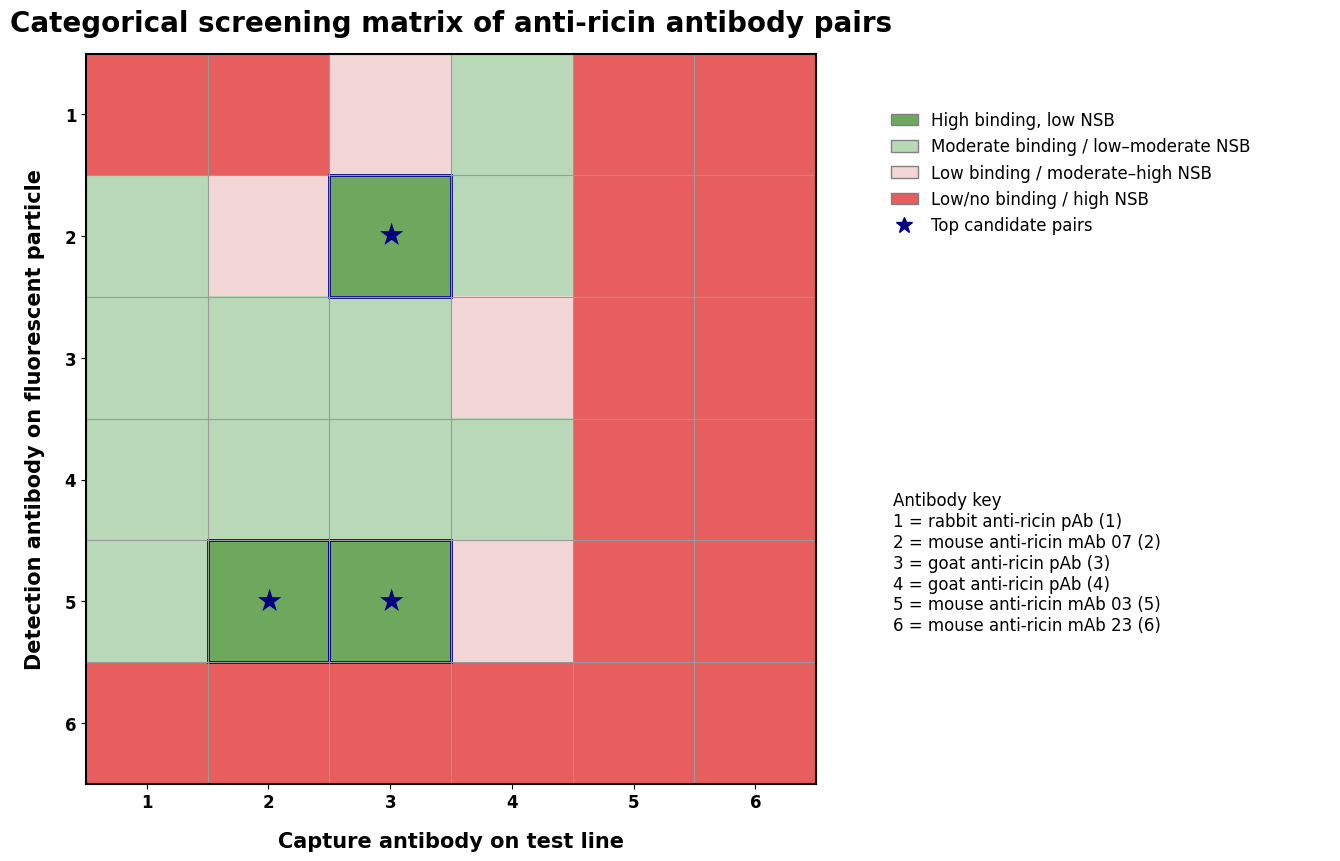

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch, Rectangle
from matplotlib.lines import Line2D

# =========================================================
# 1. Axis labels
# =========================================================
axis_labels = ["1", "2", "3", "4", "5", "6"]

# =========================================================
# 2. Categorical performance matrix
# =========================================================
# 0 = low or no binding and/or high NSB
# 1 = low binding and/or moderate-high NSB
# 2 = moderate binding and/or low-moderate NSB
# 3 = high binding, low NSB

data = np.array([
    [0, 0, 1, 2, 0, 0],
    [2, 1, 3, 2, 0, 0],
    [2, 2, 2, 1, 0, 0],
    [2, 2, 2, 2, 0, 0],
    [2, 3, 3, 1, 0, 0],
    [0, 0, 0, 0, 0, 0],
])

# Top candidate cells
star_cells = [
    (1, 2),
    (4, 1),
    (4, 2),
]

# =========================================================
# 3. Softer colors
# =========================================================
colors = [
    "#e85d5d",  # muted red
    "#f3d6d6",  # pale pink
    "#b8d8b8",  # soft green
    "#6ea85f"   # darker green
]

cmap = ListedColormap(colors)
norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], cmap.N)

# =========================================================
# 4. Figure layout: heatmap + right-side info panel
# =========================================================
fig = plt.figure(figsize=(13.5, 8.5), facecolor="white", constrained_layout=True)
gs = fig.add_gridspec(1, 2, width_ratios=[3.2, 1.7])

ax = fig.add_subplot(gs[0, 0])
info_ax = fig.add_subplot(gs[0, 1])

ax.set_facecolor("white")
info_ax.set_facecolor("white")
info_ax.axis("off")

# =========================================================
# 5. Heatmap
# =========================================================
im = ax.imshow(data, cmap=cmap, norm=norm, aspect="equal")

ax.set_xticks(np.arange(len(axis_labels)))
ax.set_yticks(np.arange(len(axis_labels)))
ax.set_xticklabels(axis_labels, fontsize=12, fontweight="bold")
ax.set_yticklabels(axis_labels, fontsize=12, fontweight="bold")

ax.set_xlabel("Capture antibody on test line", fontsize=15, fontweight="bold", labelpad=14)
ax.set_ylabel("Detection antibody on fluorescent particle", fontsize=15, fontweight="bold", labelpad=14)

ax.set_title(
    "Categorical screening matrix of anti-ricin antibody pairs",
    fontsize=20,
    fontweight="bold",
    pad=16
)

# gridlines
ax.set_xticks(np.arange(-0.5, len(axis_labels), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(axis_labels), 1), minor=True)
ax.grid(which="minor", color="#9a9a9a", linestyle="-", linewidth=0.8)
ax.tick_params(which="minor", bottom=False, left=False)

# stars and outlines
for r, c in star_cells:
    ax.text(c, r, "★", ha="center", va="center", fontsize=22, color="navy", fontweight="bold")
    rect = Rectangle((c - 0.5, r - 0.5), 1, 1, fill=False, edgecolor="navy", linewidth=2.0)
    ax.add_patch(rect)

# neat border
for spine in ax.spines.values():
    spine.set_linewidth(1.5)

# =========================================================
# 6. Legend in right-side panel
# =========================================================
legend_elements = [
    Patch(facecolor="#6ea85f", edgecolor="gray", label="High binding, low NSB"),
    Patch(facecolor="#b8d8b8", edgecolor="gray", label="Moderate binding / low–moderate NSB"),
    Patch(facecolor="#f3d6d6", edgecolor="gray", label="Low binding / moderate–high NSB"),
    Patch(facecolor="#e85d5d", edgecolor="gray", label="Low/no binding / high NSB"),
    Line2D([0], [0], marker="*", color="navy", markersize=12, linestyle="None", label="Top candidate pairs")
]

info_ax.legend(
    handles=legend_elements,
    loc="upper left",
    bbox_to_anchor=(0.0, 0.93),
    frameon=False,
    fontsize=12,
    handlelength=1.6,
    borderaxespad=0.0
)

# =========================================================
# 7. Antibody key in right-side panel
# =========================================================
antibody_key = (
    "Antibody key\n"
    "1 = rabbit anti-ricin pAb (1)\n"
    "2 = mouse anti-ricin mAb 07 (2)\n"
    "3 = goat anti-ricin pAb (3)\n"
    "4 = goat anti-ricin pAb (4)\n"
    "5 = mouse anti-ricin mAb 03 (5)\n"
    "6 = mouse anti-ricin mAb 23 (6)"
)

info_ax.text(
    0.02, 0.40,
    antibody_key,
    fontsize=12,
    ha="left",
    va="top"
)

plt.show()

# Optional save
# fig.savefig("categorical_antibody_screening_matrix_clean.png", dpi=300, bbox_inches="tight")